In [2]:
import os as os 
import numpy as np
import matplotlib.pyplot as plt
import shift as sh



In [3]:
name = 'Lil10'
data = sh.importdata(name)
data = sh.cutting(data, 1)
x, B = sh.rep(data, name, save = True, mode = 0, shift = 50, para = 1, error = False) 
# mirror the data and Fourier transform
x = np.concatenate((x, -x))
B = B - np.mean(B)  
B = np.concatenate((B, B))
B = np.fft.fftshift(B)
x = np.fft.fftshift(x)

# convert x from µm to the appropriate unit (e.g., mm)
x = x 

# filter to show only values for x > 0
mask = x > 0.4
x = x[mask]
B = B[mask]

# plot the data
plt.plot(x, B**2)
plt.xlabel('x (µm)')
plt.ylabel('B^2')
plt.title('Fourier Transformed Data')
plt.show()


KeyboardInterrupt: 

/home/cbed/hannes/Dataanalysis_Tof_SIMs/shift.py:161: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


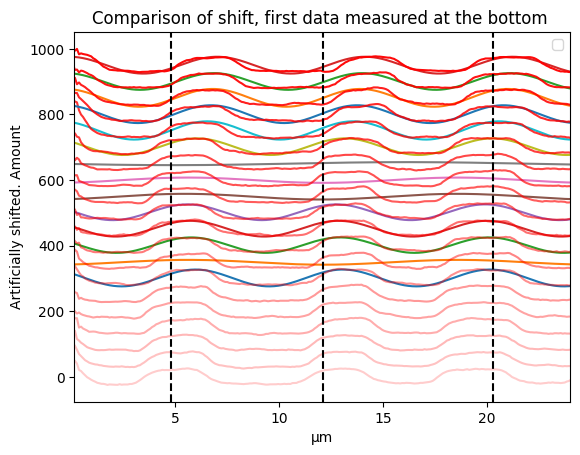

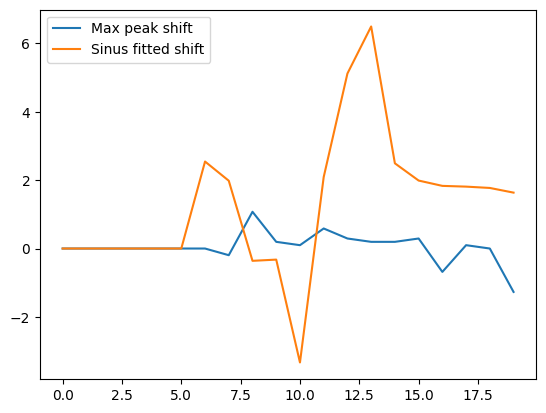

In [167]:


nameshift = 'Lil10'
data = sh.importdata(nameshift)
data = sh.cutting(data, 20)
skipa = 5
shifta, shiftpeak = sh.shiftcorrection(data, name, save = True, mode = 1, shift = 50, skipa= skipa, para=1) 
shift = [0 for i in range(skipa+1)]
shiftpeak = shiftpeak - shiftpeak[0]*np.ones(len(shiftpeak))
shiftpeak = np.append(shift, shiftpeak )*-25/256
for i in range(len(shifta)):
    if abs(shifta[i][2] - shift[-1]) > 5.2:
        shift.append(shifta[i][2] - np.pi) 
    else: 
        shift.append(shifta[i][2])
x = np.arange(len(shift))
popt = sh.fit_sin(x, shift)
#plt.plot(x,sinfunc(x,*popt) )
plt.plot(x, shiftpeak, label = 'Max peak shift')
plt.plot(shift, label='Sinus fitted shift')
plt.legend()



In [ ]:
shiftpeak = shiftpeak - 1

In [183]:

from decimal import Decimal as DE
from scipy.signal import find_peaks
def comparison_fig(namearray, para = 0, mode =1):
    saveBa = [[]for i in range(len(namearray))] 
    Bunca = [[]for i in range(len(namearray))]

    for i in range(len(namearray)):
        x, Ba, Bunc = sh.gethosum(namearray[i], shiftpeak, lowerlimit = 3, upperlimit = 20, stackno = 20, para = para, error= True )
        saveBa[i] = Ba
        Bunca[i] = Bunc
    color = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'black', 'pink', 'brown', 'grey', 'cyan', 'magenta', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy', 'olive', 'silver', 'aqua', 'fuchsia', 'lime', 'teal', 'indigo', 'maroon', 'navy']
    #namearray = [ 'CdO10', 'Cr10', 'Mg10', 'Bi10']

    absorrel = 'rel'
    fig, ax = plt.subplots(figsize=(8,6))
    for i in range(len(namearray)):
        Ba = saveBa[i]
        Bunc = Bunca[i]

        up = max(Ba[40:220])
        un = min(Ba[40:220])
        k = 2*(Ba )/(up+un)
        dif = round((max(k[50:170])- min(k[50:170]))*100,2)
        if absorrel == 'abs':
            Ba = Ba
        else:
            Ba = (Ba - un)/(up-un)
            Bunc = Bunc/(up-un)
        if i == 0: 
            print(namearray[i])
            kl = np.ones(len(Ba))/(abs(Ba)-1/2)
            peaks = find_peaks(kl, threshold=5)
        print(namearray[i]+'i', dif,  int(up), int(un), int(up-un))
        if absorrel == 'abs':
            ax.plot(x, Ba+i, label = namearray[i][:-2]+ '+', linewidth = 3)
            ax.set_yscale('log')
            ax.set_ylim(100000, 1)
            
        else:
            #ax.plot(x, Ba+i, label = namearray[i]+ '+', linewidth = 3)
            ax.errorbar(x, Ba+i, yerr=Bunc, label=namearray[i]+ '+', linewidth=1, ecolor='black', capsize=2, capthick=2, fmt='o', markersize=8)

            ax.axhline(i+0.5, color='black', linestyle='--')
            ax.text(-2, i+0.5, namearray[i][:-2]+ '+' , color='black', fontsize=18)
            #ax.text(24, i+0.5, 'Ave. A.= ' + '%.2E' % DE(up) , color='black', fontsize=18)
            ax.set_xlim(4, 23)
        ax.set_ylim(-0.3,len(namearray)+ 0.3)
        
    for i in range(len(peaks[0])):
        ax.axvline(x[peaks[0][i]], color='black', linestyle='--', alpha = 0.3)
    print(peaks)
    ax.set_xlim(4, 23)
    names = ''
    for i in namearray:
        names = names + i[:-2] + '_'
    # increase axis thickness
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(2)
    ax.set_xlabel('x (µm)', fontsize=18)
    ax.set_ylabel('Relative intensity', fontsize=18)

    plt.tight_layout()
    plt.savefig('Figures2/'+ names + 'para' + str(para)+'.png')
    plt.plot()

Cd10
Cd10i 12.61 179 157 22
Li10i 3.15 334198 323831 10367
(array([  6,  23,  26,  29,  33,  35,  39,  41,  49,  83, 127, 129, 132,
       134, 141, 145, 165, 174, 193, 203, 208, 220, 228, 231, 237, 252]), {'left_thresholds': array([ 145.40799119,  329.65816371,   34.24025009,   14.22119055,
          5.20218735,   44.8592254 ,   55.73602632,    8.79137526,
        101.26800219,    6.5718243 ,    7.18054293,  222.24700945,
         25.35236175,  105.1930821 ,   55.86126118,  271.27274709,
         31.40583075,   47.86793265, 1257.01103271,    5.87544252,
         58.51422813,   29.90903357,    5.88012738,  499.56752419,
         42.18189891,    7.31663041]), 'right_thresholds': array([ 154.39835452,  250.07108968,   31.97154283,   13.0860895 ,
         49.050963  ,   45.86686915,   25.26000746,   12.42056958,
         75.99382721,    9.10016874,  258.80351515,   64.07544512,
         78.45040185,   91.64895646,   41.08166015,  356.98700574,
         38.13761579,    7.11192321, 1462.348

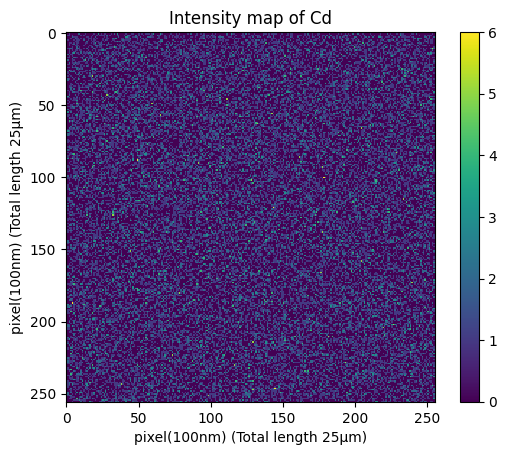

<Figure size 640x480 with 0 Axes>

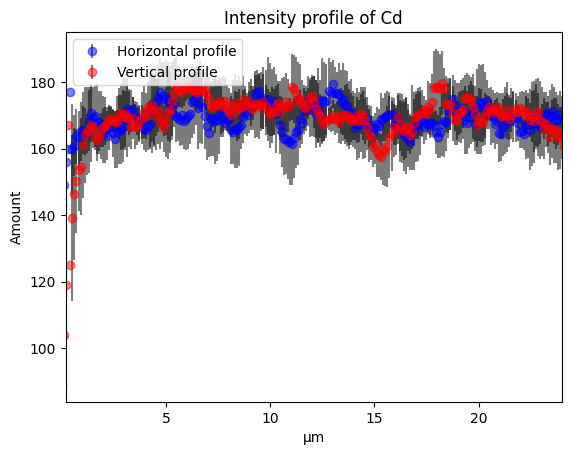

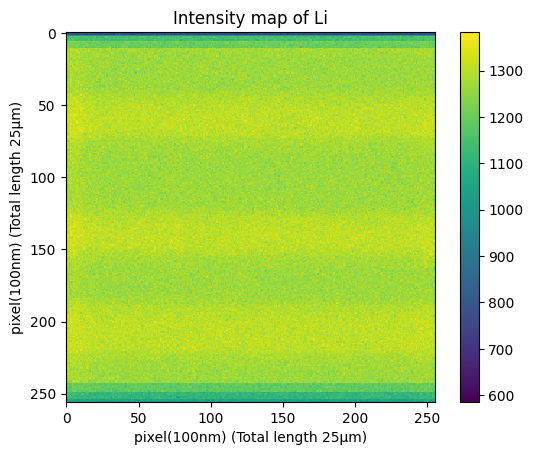

<Figure size 640x480 with 0 Axes>

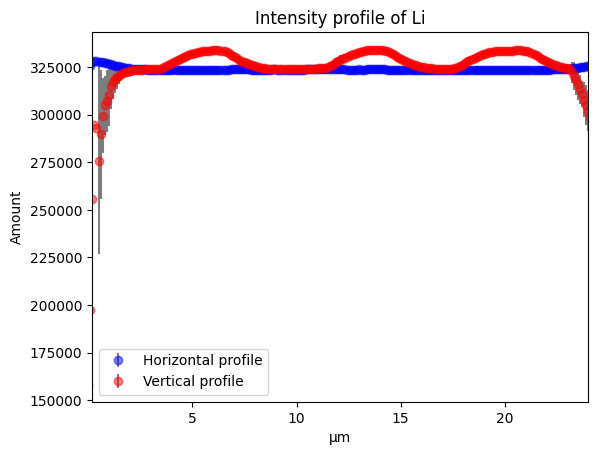

<Figure size 640x480 with 0 Axes>

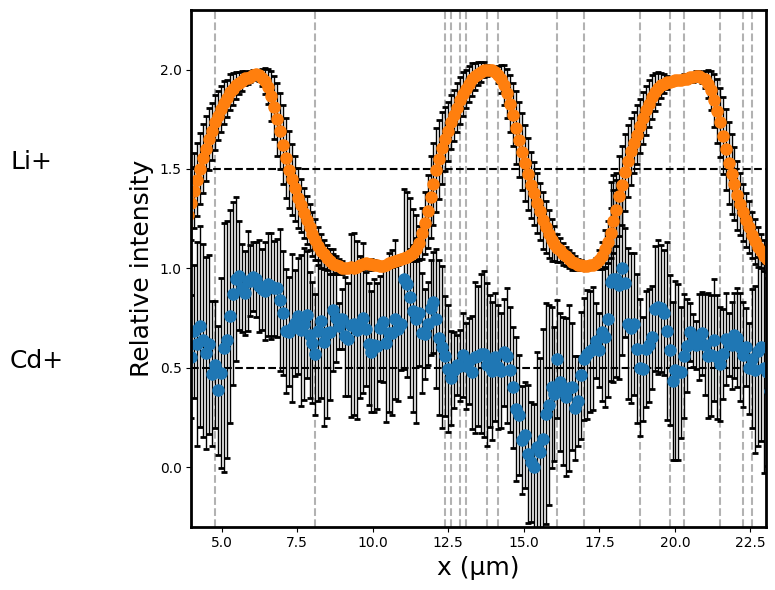

In [184]:
comparison_fig([  'Cd10', 'Li10' ], para = 1, mode = 1)

Lil10
Lil10i 4.51 233947 223635 10312
Nbl10i 5.63 9357 8844 512
O10i 6.35 1169 1097 71
NbLiO10i 8.09 753 694 58
NbLiO210i 9.31 3308 3014 294
NbO10i 0.55 70832 70285 547
(array([ 11,  45,  73, 125, 154, 189, 223, 241]), {'left_thresholds': array([16.04429968, 97.27118086, 17.07086337, 88.95374373, 37.93614155,
       82.14820831, 25.66913457, 44.09055925]), 'right_thresholds': array([31.49200682, 13.38189671, 79.57125306, 14.40271562, 79.82533149,
       12.98466031, 73.92285423, 30.8709356 ])})


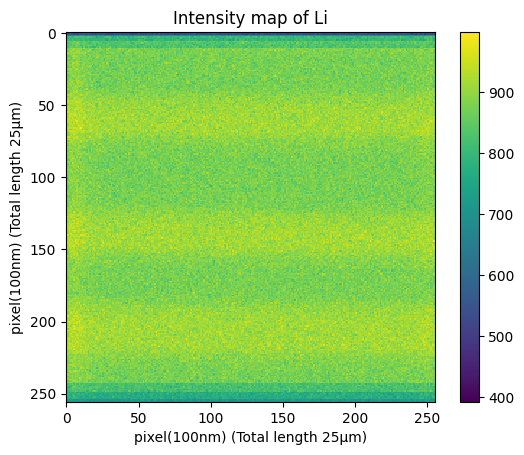

<Figure size 640x480 with 0 Axes>

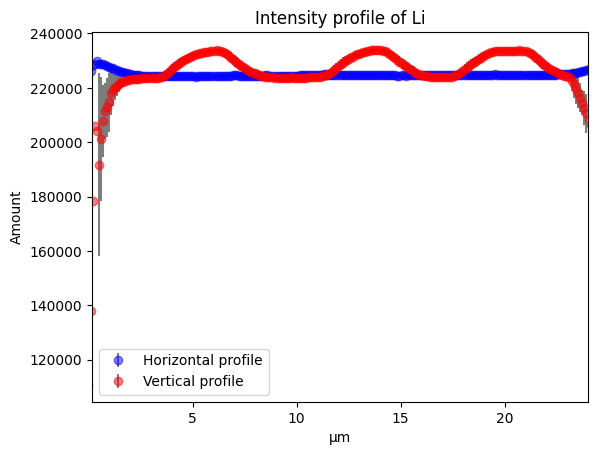

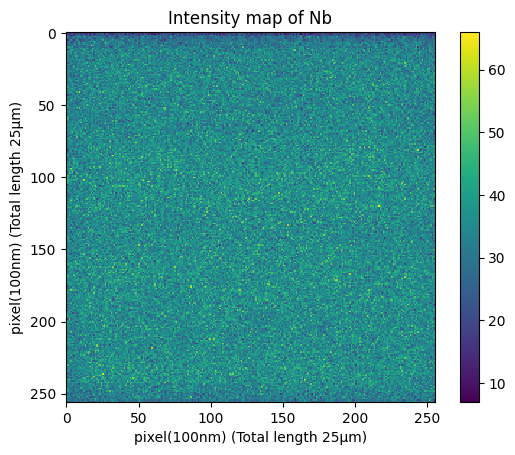

<Figure size 640x480 with 0 Axes>

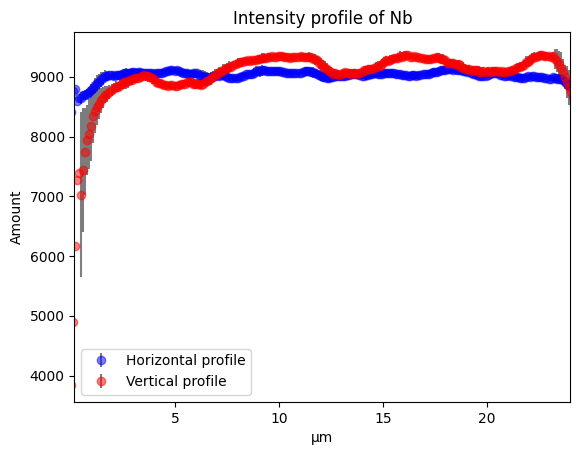

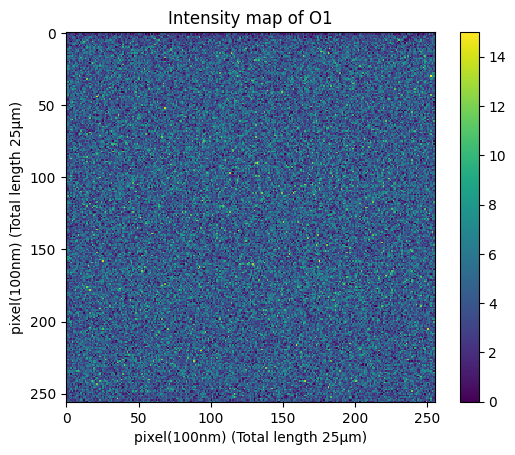

<Figure size 640x480 with 0 Axes>

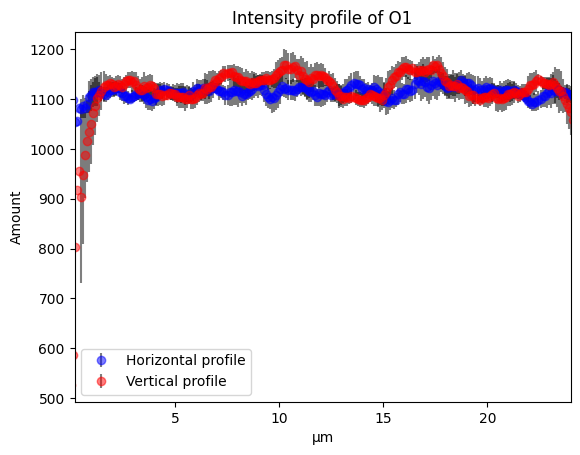

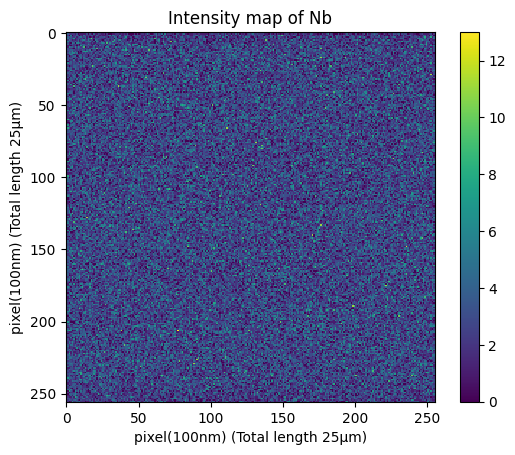

<Figure size 640x480 with 0 Axes>

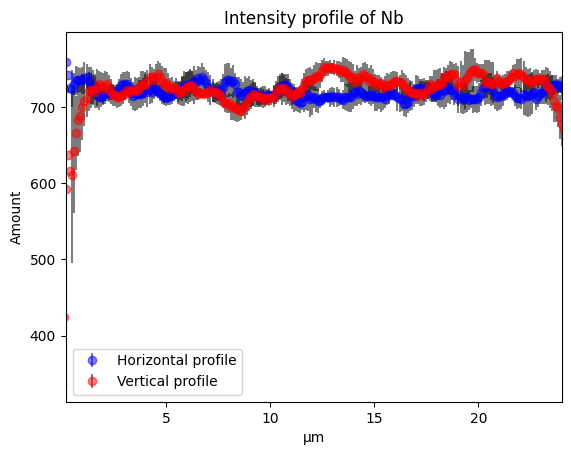

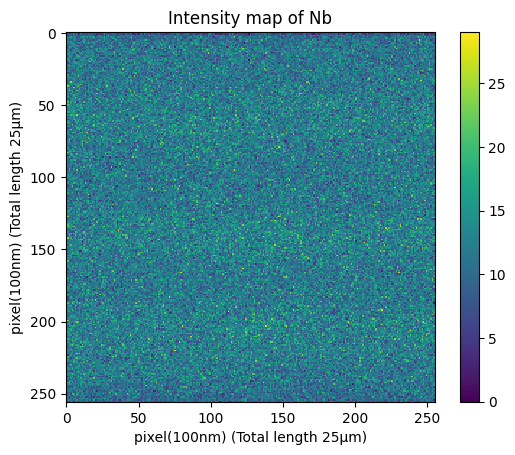

<Figure size 640x480 with 0 Axes>

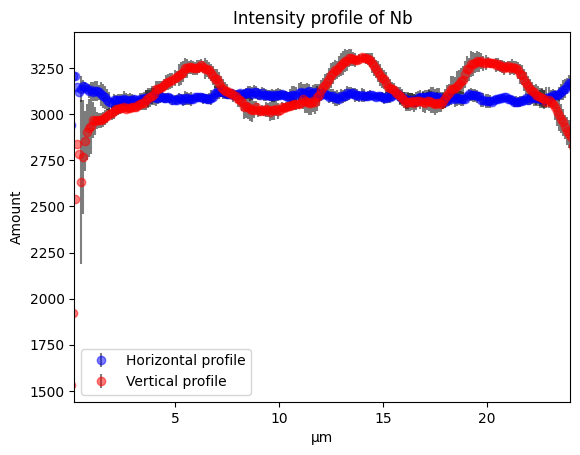

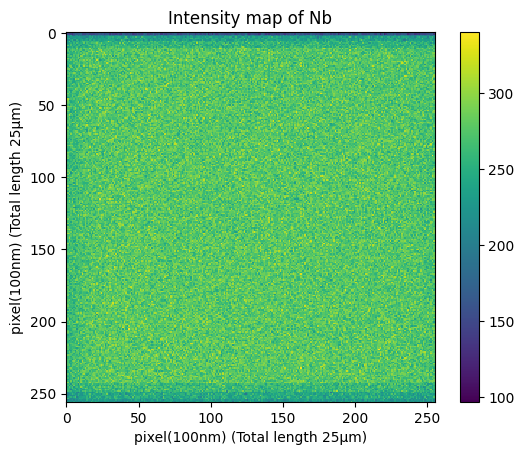

<Figure size 640x480 with 0 Axes>

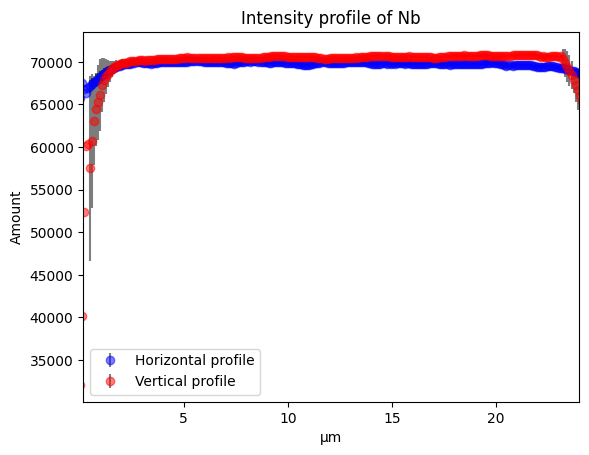

<Figure size 640x480 with 0 Axes>

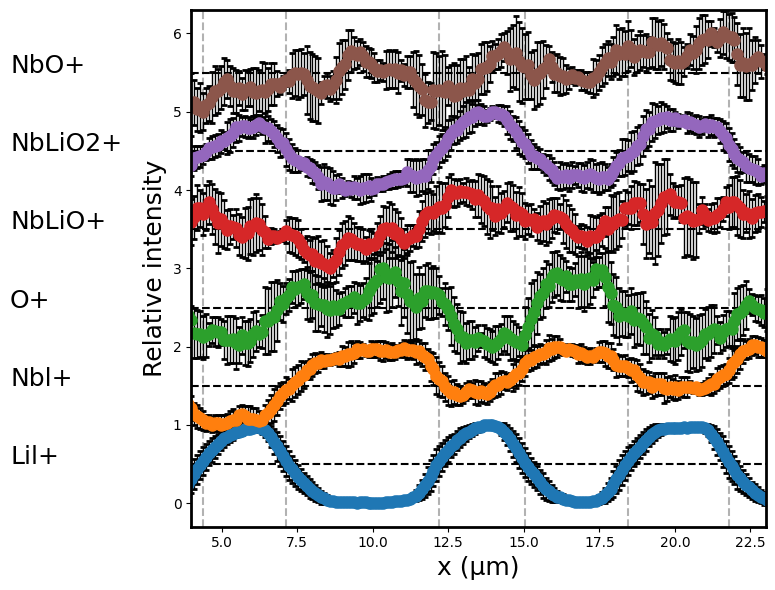

In [186]:
namearray = ['Lil10','Liu10', 'Cdu10'] #'Nbl10','Nb10', 'Na10','K10', 'Li_2O_210', 'Cd10', 'O10', 'Bi10']
#namearray = [ 'CdO10', 'Cr10', 'Mg10', 'Bi10']
# basic [Li10, Lil10, Liu10,Nb10, Nbl10, Nbu10]
# basic2 ['Lil10', 'Nbl10', 'Cd10', 'Cdl10', 'Cdu10']
# 

namearray = []
# namearray.append(['Li10', 'Lil10', 'Liu10','Nb10', 'Nbl10', 'Nbu10'])
# namearray.append(['Lil10', 'Nbl10', 'Cd10','Cdl10','Cdu10', 'CdO10'])
# namearray.append(['Lil10', 'Cr10', 'Bi10', 'K10', 'Li_2O_210', 'Mg10'])
# namearray.append(['Lil10', 'Na10', 'Nal10', 'Nau10', 'O10'])
namearray.append(['Lil10', 'Nbl10', 'O10', 'NbLiO10','NbLiO210', 'NbO10' ])

for d in range(1, 2):
    for i in range(len(namearray)):
        
        comparison_fig(namearray[i], d)


In [213]:
data = sh.importdata('Lil10')
data = sh.cutting(data, 2)
dmap = data[0]  

[105.         106.63157895 108.26315789 109.89473684 111.52631579
 113.15789474 114.78947368 116.42105263 118.05263158 119.68421053
 121.31578947 122.94736842 124.57894737 126.21052632 127.84210526
 129.47368421 131.10526316 132.73684211 134.36842105 136.        ]


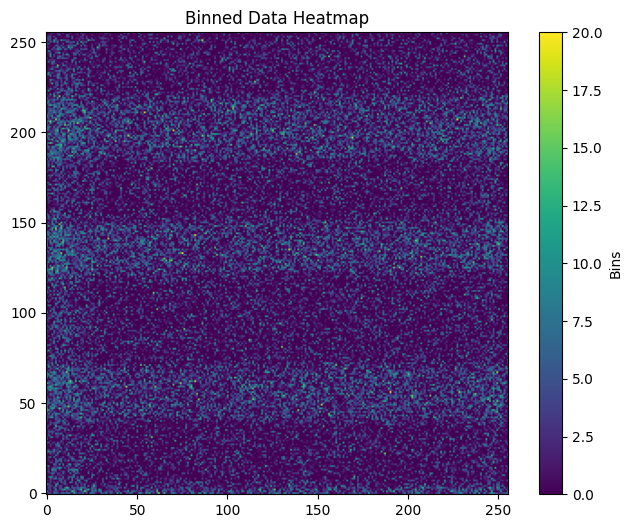

In [218]:
dmap = data[1]
# dmap = dmap / dmap.mean(axis = 0) -1
# positivemap = np.zeros((256, 256))
# for i in range(256):
#     for j in range(256):
#         if dmap[i][j]>-0.001:
#             positivemap[i][j]=1
# write another algorithm that bins into 10 bins and saves these bins from 1  to 10 in a new array
# then plot the array in a heatmap
# Bin the data into 10 bins
bins = np.linspace(np.median(dmap), dmap.max(), 20)
print(bins)
binned_map = np.digitize(dmap, bins)

# Plot the binned array in a heatmap
plt.figure(figsize=(8, 6))
plt.imshow(binned_map, cmap='viridis', origin='lower')
plt.colorbar( label='Bins')
plt.title('Binned Data Heatmap')
plt.show()








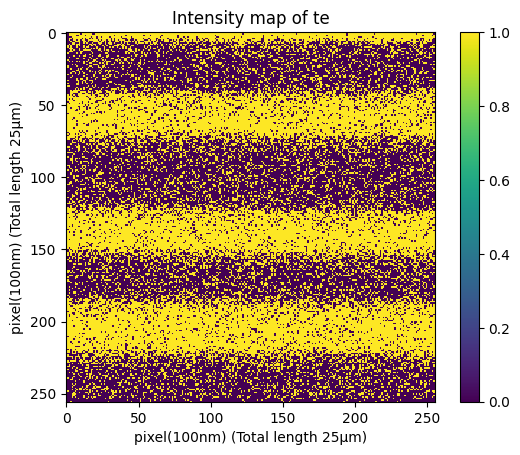

<Figure size 640x480 with 0 Axes>

In [ ]:
sh.plotmap(positivemap, 'test ')

In [ ]:
data = sh.importdata('Lil10')
data = sh.cutting(data, 3)
  
print(data.shape)



(3, 256, 256)


(250.0, 450.0)

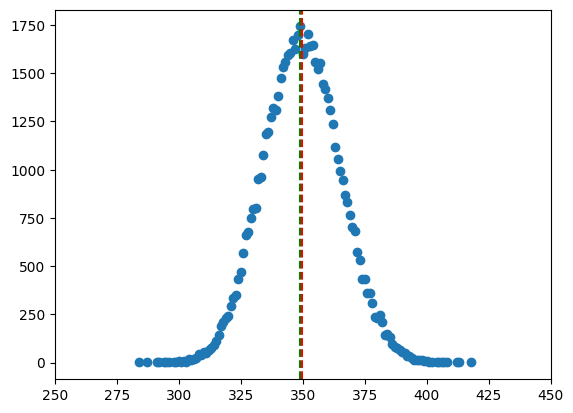

In [193]:
# count and plot the number of pixels with the same value
unique, counts = np.unique(data[0], return_counts=True)
plt.plot(unique, counts, 'o')
# add a vertical line to indicate the mean value and median value

plt.axvline(np.mean(data[0]), color='red', linestyle='--', label='Mean')
plt.axvline(np.median(data[0]), color='green', linestyle='--', label='Median')
plt.xlim(250, 450)

In [140]:
data = sh.importdata('Lil10')
data = sh.cutting(data, 10)

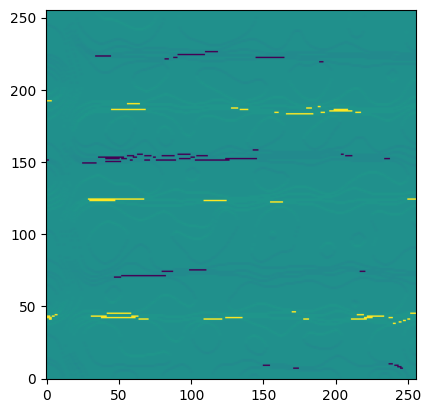

In [150]:
datax = data[5]
    
for i in range(4):
    datax = scipy.ndimage.median_filter(datax, 10)
    datax = scipy.ndimage.median_filter(datax, 7)
    datax = scipy.ndimage.median_filter(datax, 5)
    datax = scipy.ndimage.median_filter(datax, 3)
# sobel
a = 0
if a == 0:
    datax = scipy.ndimage.sobel(datax, axis=0)
    datax[datax <-6] = -100
    datax[datax > 6] = 100
# Plot the horizontal line
# image plot

plt.imshow(datax, cmap='viridis', origin='lower')
   

[array([215, 134,  71]), array([214, 132,  70]), array([215, 134,  70]), array([209, 132,  67]), array([203, 122,  58])]
[array([247, 182, 104,  34]), array([248, 181, 102,  31]), array([248, 182, 100,  30]), array([246, 180, 100,  30]), array([241, 173,  94,  23])]


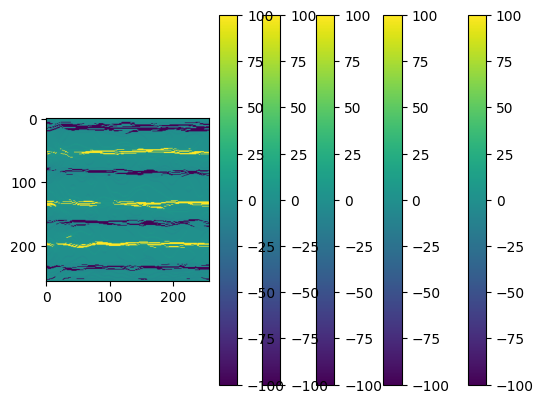

In [130]:
hpeaka = []
lpeaka = []

import scipy.ndimage
for i in range(len(data)):
    datax = data[i]
    for i in range(4):
        datax = scipy.ndimage.median_filter(datax, 10)
        datax = scipy.ndimage.median_filter(datax, 7)
        datax = scipy.ndimage.median_filter(datax, 5)
        datax = scipy.ndimage.median_filter(datax, 3)
    # sobel
    a = 0
    if a == 0:
        datax = scipy.ndimage.sobel(datax, axis=0)
        datax[datax <-6] = -100
        datax[datax > 6] = 100
    # Plot the horizontal line
   
 
    plt.imshow(datax, cmap = 'viridis')
    plt.colorbar()
    datav = datax.sum(axis=1)
    hpeaks, _ = find_peaks(datav[:-10], distance=60, height=200)# before 300 
    lpeaks, _ = find_peaks(-datav, distance=50, height=200)
    if len(lpeaks) != 4:
        lpeaks = 256-lpeaka[-1]
    if len(hpeaks) != 3:
        hpeaks = 256-hpeaka[-1]

    lpeaka.append(256-lpeaks)
    hpeaka.append(256-hpeaks)
print(hpeaka)
print(lpeaka)


[[182 104  34]
 [181 102  31]
 [182 100  30]
 [180 100  30]
 [173  94  23]]
[0 1 2 3 4]


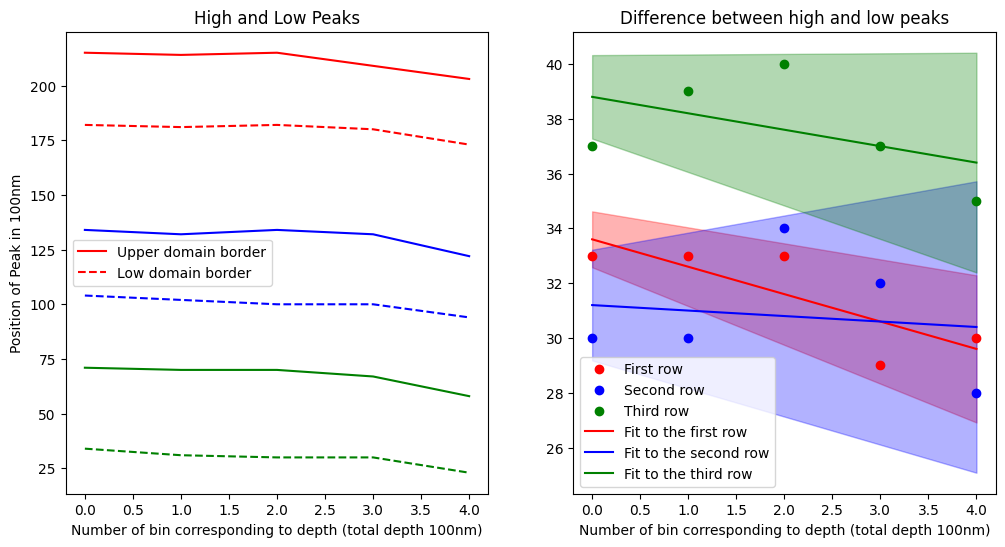

In [131]:

hpeaka = np.array(hpeaka)
lpeaka = np.array(lpeaka)
x = np.arange(len(hpeaka[:,1]))
lpeakam = lpeaka[:,1:]
# create two subplots with ax
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].set_title('Li 7 bins domain borders')

ax[0].plot(x, hpeaka[:,0], color='red', label='Upper domain border')
ax[0].plot(x, hpeaka[:,1], color='blue' )
ax[0].plot(x, hpeaka[:,2], color='green' )
ax[0].plot(x, lpeakam[:,0], color='red', linestyle='--', label='Low domain border')
ax[0].plot(x, lpeakam[:,1], color='blue', linestyle='--')
ax[0].plot(x, lpeakam[:,2], color='green', linestyle='--')

ax[0].set_title('High and Low Peaks')
ax[0].set_xlabel('Number of bin corresponding to depth (total depth 100nm)')
ax[0].set_ylabel('Position of Peak in 100nm')
ax[0].legend()

# remove from low peaka the first row

print(lpeakam)
dif = hpeaka - lpeakam
ax[1].plot(x, dif[:,0], color='red', label='First row', marker='o', linestyle='None')
ax[1].plot(x, dif[:,1], color='blue', label='Second row', marker='o', linestyle='None')
ax[1].plot(x, dif[:,2], color='green', label='Third row', marker='o', linestyle='None')


ax[1].set_title('Difference between high and low peaks')
ax[1].set_xlabel('Number of bin corresponding to depth (total depth 100nm)')
# fit linear function to the difference
x = np.arange(len(dif))
print(x)
def linfunc(x, a, b):
    return a*x + b
# liner fit
from scipy.optimize import curve_fit
popt1, pcov1 = curve_fit(linfunc, x, dif[:,0])
popt2, pcov2 = curve_fit(linfunc, x, dif[:,1])
popt3, pcov3 = curve_fit(linfunc, x, dif[:,2])
# Plot the fit with error tube around it
error = np.sqrt(np.diag(pcov1))
ax[1].plot(x, linfunc(x, *popt1), color='red', label='Fit to the first row')
ax[1].fill_between(x, linfunc(x, popt1[0]-error[0], popt1[1]-error[1]), linfunc(x, popt1[0]+error[0], popt1[1]+error[1]), color='red', alpha=0.3)

error = np.sqrt(np.diag(pcov2))
ax[1].plot(x, linfunc(x, *popt2), color='blue', label='Fit to the second row')
ax[1].fill_between(x, linfunc(x, popt2[0]-error[0], popt2[1]-error[1]), linfunc(x, popt2[0]+error[0], popt2[1]+error[1]), color='blue', alpha=0.3)

error = np.sqrt(np.diag(pcov3))
ax[1].plot(x, linfunc(x, *popt3), color='green', label='Fit to the third row')
ax[1].fill_between(x, linfunc(x, popt3[0]-error[0], popt3[1]-error[1]), linfunc(x, popt3[0]+error[0], popt3[1]+error[1]), color='green', alpha=0.3)
ax[1].legend()






[ 41 123 185]


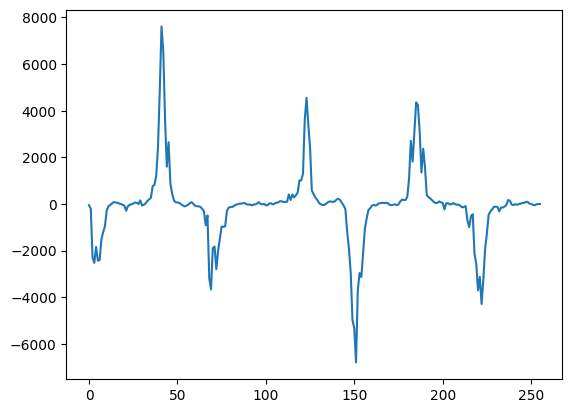

In [142]:
datav = datax.sum(axis=1)
# get the position of the peaks the minimum distance between peaks is 10

peaks, _ = find_peaks(datav, distance=10, height=4000)
print(peaks)
plt.plot(datav)



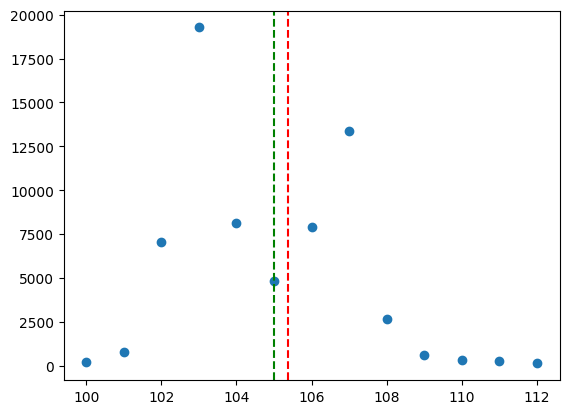

In [252]:
# count and plot the number of pixels with the same value
unique, counts = np.unique(datax, return_counts=True)
plt.plot(unique, counts, 'o')
# add a vertical line to indicate the mean value and median value

plt.axvline(np.mean(data[0]), color='red', linestyle='--', label='Mean')
plt.axvline(np.median(data[0]), color='green', linestyle='--', label='Median')
